# FraudLens - Phase 1: Exploratory Data Analysis

Goal: understand the dataset before modeling. Specifically, quantify the class
imbalance and get a first feel for whether features carry any signal about fraud.

## Loading the data

The dataset is ~285,000 credit-card transactions. Features `V1`–`V28` are
anonymized (PCA-transformed for privacy), plus `Time`, `Amount`, and `Class`
(0 = legitimate, 1 = fraud).

In [1]:
import pandas as pd

df = pd.read_csv("data/raw/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df.shape

(284807, 31)

## Checking data quality

Verifying there are no missing values before trusting the data.

In [3]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## The central challenge: class imbalance

Fraud is only ~0.17% of transactions. This shapes every later decision, it's
why accuracy is a useless metric here and why we'll evaluate with precision,
recall, and AUPRC instead.

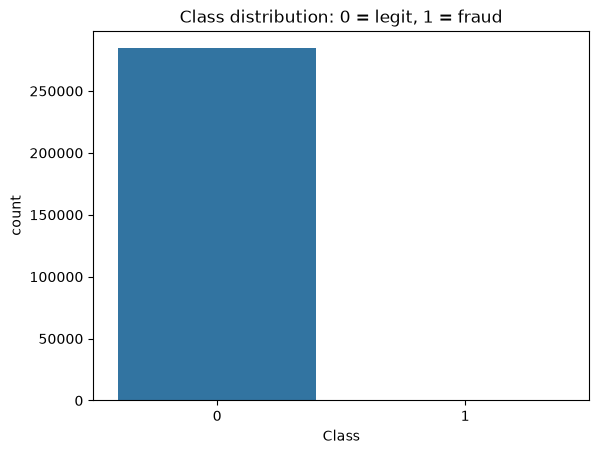

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Class")
plt.title("Class distribution: 0 = legit, 1 = fraud")
plt.show()

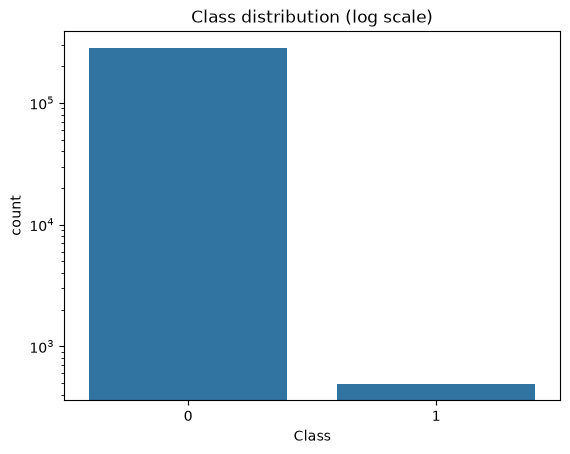

In [5]:
sns.countplot(data=df, x="Class")
plt.title("Class distribution (log scale)")
plt.yscale("log")
plt.show()

## Does transaction amount differ between fraud and legit?

Comparing amount statistics across classes. Note mean vs median: fraud has a
higher mean but *lower* median, meaning most fraud is small with a few larger
outliers pulling the average up. Amount carries weak signal on its own.

In [6]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


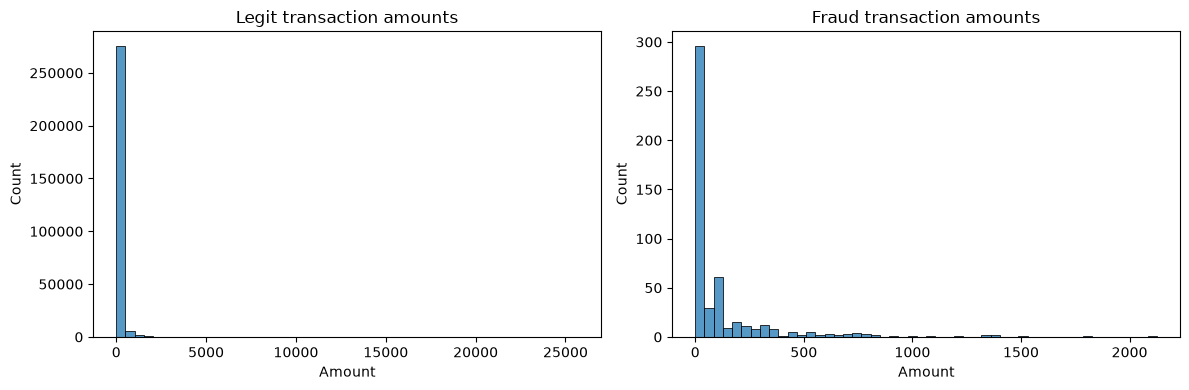

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df[df["Class"] == 0], x="Amount", bins=50, ax=axes[0])
axes[0].set_title("Legit transaction amounts")

sns.histplot(data=df[df["Class"] == 1], x="Amount", bins=50, ax=axes[1])
axes[1].set_title("Fraud transaction amounts")

plt.tight_layout()
plt.show()

## Phase 1 summary

- ~284,807 transactions, 31 columns, no missing values.
- Severe imbalance: 0.17% fraud → accuracy is misleading; use precision/recall/AUPRC.
- `Amount` differs slightly between classes but no single feature cleanly
  separates fraud. Motivates a multi-feature model.